<a href="https://colab.research.google.com/github/bobo33772-blip/aix_13_python/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EC%A0%84%EC%B2%B4%EB%A6%AC%EB%B7%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
# fish.csv로딩
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv')
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


In [82]:
fish['Species'].value_counts()

,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


In [83]:
# 기초 통계량
fish.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


In [84]:
# 문자데이터 기초 통계치
fish.describe(include='object')

,Species
count,159
unique,7
top,Perch
freq,56


<Axes: >

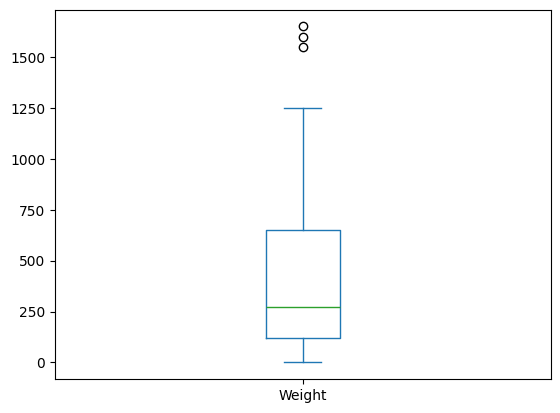

In [85]:
# 회귀 - 무게(Weight)
# 이상치 파악
# fish['Weight'].plot(kind='box')
fish['Weight'].plot.box()

In [86]:
# 특성과 타겟 분리
fish_input = fish[['Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Weight']

# 모델선택 - K최근접이웃
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()
knr.get_params()

# 훈련데이터, 테스트 데이터 분할
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)
# 훈련
knr.fit(train_input, train_target)
# 훈련 점수
train_score = knr.score(train_input, train_target)
print('train score=', train_score)
# 테스트점수
test_score = knr.score(test_input, test_target)
print('test_score=',test_score)

train score= 0.9583572271576069
test_score= 0.9722110983879799


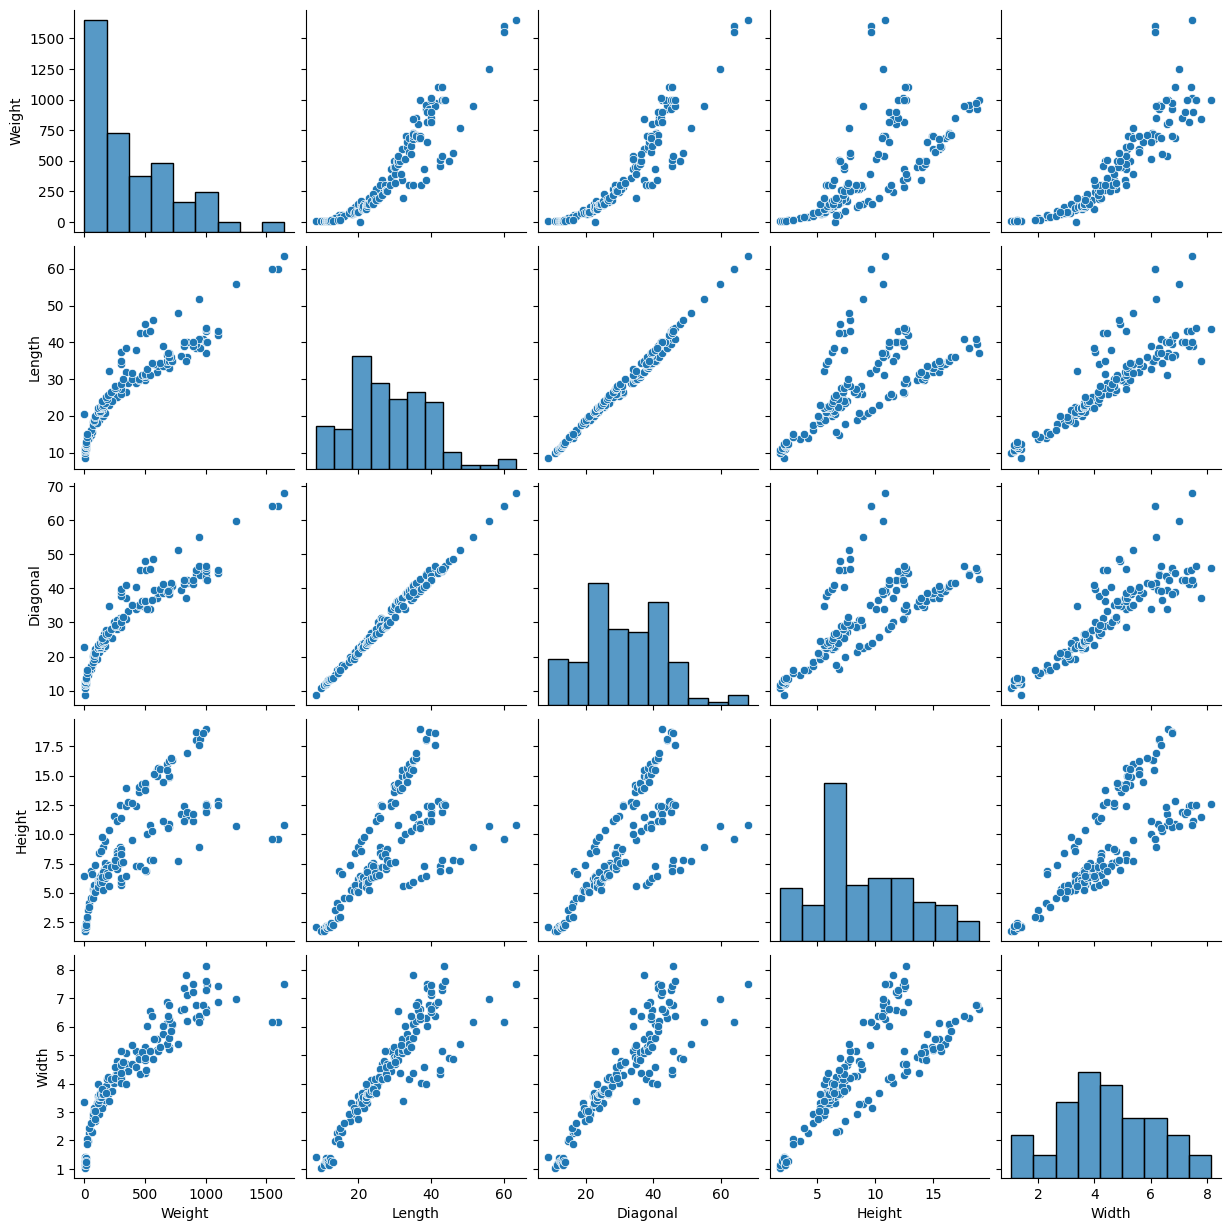

In [87]:
# 페어플랏(pairplot) - 모든 칼럼별 산포도 그래프
import seaborn as sns
sns.pairplot(fish)

In [88]:
# 분류 - 어종(Species)
# K최근접이웃 분류
from sklearn.neighbors import KNeighborsClassifier

# 입력(X), 정답(y)
X = fish[['Weight','Length','Diagonal','Height','Width']]
y = fish['Species']

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


# KNN 모델
knn = KNeighborsClassifier(n_neighbors=5)

# 학습
knn.fit(X_train, y_train)

# 훈련 점수
train_score = knn.score(X_train, y_train)
print('train score=', train_score)
# 테스트점수
test_score = knn.score(X_test, y_test)
print('test_score=',test_score)

train score= 0.6722689075630253
test_score= 0.575


In [89]:
# 이상치 수치로 파악
Q1 = fish['Weight'].quantile(0.25)
Q3 = fish['Weight'].quantile(0.75)
MIN = Q1 - (1.5 * (Q3 - Q1))
MAX = Q3 + (1.5 * (Q3 - Q1))
print('MIN=',MIN)
print('MAX=',MAX)
outliers = fish.query('Weight < @MIN | Weight > @MAX')
outliers

MIN= -675.0
MAX= 1445.0


,Species,Weight,Length,Diagonal,Height,Width
142,Pike,1600.0,60.0,64.0,9.600,6.144
143,Pike,1550.0,60.0,64.0,9.600,6.144
144,Pike,1650.0,63.4,68.0,10.812,7.480


In [90]:
fish_droped = fish.drop(index=outliers.index)
fish_droped

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 입력(X), 정답(y)
X = fish[['Weight','Length','Diagonal','Height','Width']]
y = fish['Species']

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 모델 생성
knn = KNeighborsClassifier(n_neighbors=5)

# 학습
knn.fit(X_train, y_train)

# 훈련 점수
train_score = knn.score(X_train, y_train)
print('train score=', train_score)

# 테스트 점수
test_score = knn.score(X_test, y_test)
print('test score=', test_score)

train score= 0.6722689075630253
test score= 0.575


In [92]:
# 선형회귀 모델 / 선형분류X 로지스틱회귀(분류)
# 무게 예측

# 특성과 타겟 분리
X = fish[['Length','Diagonal','Height','Width']]
y = fish['Weight']

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 스케일링 (train 기준)
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

# 모델
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# 훈련
model.fit(X_train, y_train)

# 훈련 점수
train_score = model.score(X_train, y_train)
print('train score=', train_score)

# 테스트 점수
test_score = model.score(X_test, y_test)
print('test score=', test_score)

train score= 0.8832205123776352
test score= 0.8792941906217031


In [93]:
# 기울기, 절편
print('가중치',model.coef_)
print('절편',model.intercept_)

가중치 [ 575.95229202 -332.68679385   90.88810292   30.6235147 ]
절편 393.2722689075635


<Axes: xlabel='Length', ylabel='Weight'>

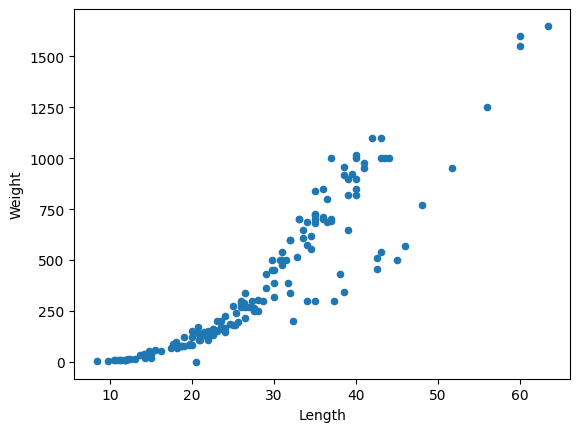

In [94]:
# 길이와 무게의 산포도
fish.plot.scatter(x='Length', y='Weight')

In [95]:
# 선형회귀 모델 / 선형분류X 로지스틱회귀(분류)
# 무게 예측

# 특성과 타켓 분리
# fish_input=fish[['Length','Diagonal','Height','Width']]
fish_input=fish[['Length',]]
fish_target=fish['Weight']
# Length의 제곱항을 추가
fish_input['Length_2']=fish_input['Length']**2

#모델선택 - 선형회귀
from sklearn.linear_model import LinearRegression
model=LinearRegression()

#훈련데이터, 테스트 데이터 분할
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target=train_test_split(
    fish_input, fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

#훈련
model.fit(train_scaled, train_target)

#훈련 세트 평가
train_score=model.score(train_scaled, train_target)
print('train score=', train_score)

#테스트
test_score=model.score(test_scaled, test_target)
print('test score=', test_score)


train score= 0.868501741708265
test score= 0.8169593198446241


/tmp/ipykernel_8291/1482236317.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fish_input['Length_2']=fish_input['Length']**2


In [96]:
print(model.coef_)
print(model.intercept_)

[149.9790226  183.56207019]
393.2722689075631


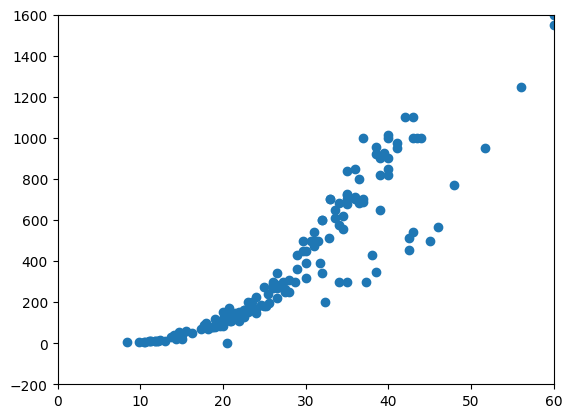

In [97]:
# 길이와 무게의 산포도
# fish.plot.scatter(x='Length', y='Weight')
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(fish['Length'], fish['Weight'])
plt.xlim(0,60)
plt.ylim(-200,1600)
y = np.arange(10,60)
plt.plot(y, 149.9*y**2+183*y+393)

In [98]:
# 다항회귀
# 선형회귀 모델 / 선형분류X 로지스틱회귀(분류)
# 무게 예측

# 특성과 타켓 분리
# fish_input=fish[['Length','Diagonal','Height','Width']]
fish_input=fish[['Length','Diagonal','Width']]
fish_target=fish['Weight']
# Length','Diagonal','Width의 제곱칼럼을 추가
fish_input['Length_2']=fish_input['Length']**2
fish_input['Diagonal_2']=fish_input['Diagonal']**2
fish_input['Width_2']=fish_input['Width']**2

# fish_input에 polynormial features 적용
from sklearn.preprocessing import PolynomialFeatures
# 기본 2제곱항 추가 degree=2
poly=PolynomialFeatures(include_bias=False)
poly.fit(fish_input)
poly_input=poly.transform(fish_input)

#모델선택 - 선형회귀
from sklearn.linear_model import LinearRegression
model=LinearRegression()

#훈련데이터, 테스트 데이터 분할
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target=train_test_split(
    poly_input, fish_target, random_state=42)

#훈련
model.fit(train_input, train_target)

#훈련 세트 평가
train_score=model.score(train_input, train_target)
print('train score=', train_score)

#테스트
test_score=model.score(test_input, test_target)
print('test score=', test_score)
# train score= 0.8774033001678883
# test score= 0.869886728819794
# train score= 0.9728678374553776
# test score= 0.9621047706912566

train score= 0.9857972518311331
test score= 0.9645188181866536


/tmp/ipykernel_8291/1530934139.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fish_input['Length_2']=fish_input['Length']**2
/tmp/ipykernel_8291/1530934139.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fish_input['Diagonal_2']=fish_input['Diagonal']**2


In [99]:
poly.feature_names_in_

array(['Length', 'Diagonal', 'Width', 'Length_2', 'Diagonal_2', 'Width_2'],
      dtype=object)

In [100]:
poly.get_feature_names_out()

array(['Length', 'Diagonal', 'Width', 'Length_2', 'Diagonal_2', 'Width_2',
       'Length^2', 'Length Diagonal', 'Length Width', 'Length Length_2',
       'Length Diagonal_2', 'Length Width_2', 'Diagonal^2',
       'Diagonal Width', 'Diagonal Length_2', 'Diagonal Diagonal_2',
       'Diagonal Width_2', 'Width^2', 'Width Length_2',
       'Width Diagonal_2', 'Width Width_2', 'Length_2^2',
       'Length_2 Diagonal_2', 'Length_2 Width_2', 'Diagonal_2^2',
       'Diagonal_2 Width_2', 'Width_2^2'], dtype=object)

In [101]:
# 로지스틱 회귀 모델(분류)

# 어종 예측

# 특성과 타켓 분리
# fish_input=fish[['Length','Diagonal','Height','Width']]
fish_input=fish[['Length','Diagonal','Height','Width']]
fish_target=fish['Species']

#모델선택 - 로지스틱회귀
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

#훈련데이터, 테스트 데이터 분할
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target=train_test_split(
    fish_input, fish_target, random_state=42)

# from sklearn.preprocessing import StandardScaler
# ss=StandardScaler()
# ss.fit(train_input)
# train_scaled=ss.transform(train_input)
# test_scaled=ss.transform(test_input)

#훈련
model.fit(train_input, train_target)

#훈련 세트 평가(정확도)
train_score=model.score(train_input, train_target)
print('train score=', train_score)

#테스트(정확도)
test_score=model.score(test_input, test_target)
print('test score=', test_score)


train score= 0.9747899159663865
test score= 0.925


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [102]:
# 결정트리 모델(분류)

# 어종 예측

# 특성과 타켓 분리
# fish_input=fish[['Length','Diagonal','Height','Width']]
fish_input=fish[['Length','Diagonal','Height','Width']]
fish_target=fish['Species']

#모델선택 - 결정트리
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

#훈련데이터, 테스트 데이터 분할
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target=train_test_split(
    fish_input, fish_target, random_state=42)

#훈련
model.fit(train_input, train_target)

#훈련 세트 평가(정확도)
train_score=model.score(train_input, train_target)
print('train score=', train_score)

#테스트(정확도)
test_score=model.score(test_input, test_target)
print('test score=', test_score)


train score= 1.0
test score= 0.75


In [103]:
'결정트리의 깊이값', model.get_depth()

('결정트리의 깊이값', 11)

In [117]:
#모델선택 - 결정트리(최대깊이 3)
# from sklearn.tree import DecisionTreeClassifier
# model=DecisionTreeClassifier(max_depth=12)

#모델선택 - 랜덤포레스트
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()

#훈련데이터, 테스트 데이터 분할
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target=train_test_split(
    fish_input, fish_target, random_state=42, stratify=fish_target)

#훈련
model.fit(train_input, train_target)

#훈련 세트 평가(정확도)
train_score=model.score(train_input, train_target)
print('train score=', train_score)

#테스트(정확도)
test_score=model.score(test_input, test_target)
print('test score=', test_score)


train score= 1.0
test score= 0.8
